# Customer Lifetime Value Prediction for Olist

## Setup

In [74]:
pip install kagglehub lifetimes xgboost

In [75]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

import kagglehub

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import (
    plot_period_transactions,
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42

DATA_PATH = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print('Dataset folder:', DATA_PATH)
print('Files:', os.listdir(DATA_PATH))

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset folder: /kaggle/input/brazilian-ecommerce
Files: ['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


---
## Task A. Data Audit and Cleaning

For CLTV I only need a subset of the tables: orders carry the timestamps and the lifecycle status, customers gives us the real shopper identifier, and payments holds the monetary value. Items would also work for revenue but payments is what the customer actually paid, freight included, so I use that.

Throughout the notebook I use `customer_unique_id` as the customer key.

In [76]:
orders = pd.read_csv(os.path.join(DATA_PATH, 'olist_orders_dataset.csv'),
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])
customers = pd.read_csv(os.path.join(DATA_PATH, 'olist_customers_dataset.csv'))
payments = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_payments_dataset.csv'))
items = pd.read_csv(os.path.join(DATA_PATH, 'olist_order_items_dataset.csv'))

print('orders   :', orders.shape)
print('customers:', customers.shape)
print('payments :', payments.shape)
print('items    :', items.shape)

orders   : (99441, 8)
customers: (99441, 5)
payments : (103886, 5)
items    : (112650, 7)


### Per-table audit

For each table I look at the obvious things: missing values, duplicates, and a quick look at the categorical distributions that matter for filtering. The interesting findings for our use case are concentrated in `orders`.

In [77]:
def audit(df, name):
    print(f'--- {name} ---')
    print('rows / cols     :', df.shape)
    print('duplicated rows :', df.duplicated().sum())
    nulls = df.isna().sum()
    print('columns with NA :')
    print(nulls[nulls > 0] if nulls.sum() else '  none')
    print()

for name, df in [('orders', orders), ('customers', customers),
                 ('payments', payments), ('items', items)]:
    audit(df, name)

--- orders ---
rows / cols     : (99441, 8)
duplicated rows : 0
columns with NA :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- customers ---
rows / cols     : (99441, 5)
duplicated rows : 0
columns with NA :
  none

--- payments ---
rows / cols     : (103886, 5)
duplicated rows : 0
columns with NA :
  none

--- items ---
rows / cols     : (112650, 7)
duplicated rows : 0
columns with NA :
  none



orders that were not delivered (cancelled, unavailable, still shipping) have empty delivery timestamps, and 160 approvals are missing. None of this affects the CLTV analysis because I will only use `order_purchase_timestamp` (no nulls) for the time axis and `payment_value` from the payments table (no nulls) for the monetary value. The delivery-date columns are not used downstream.

The relevant distribution for filtering is `order_status`.

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


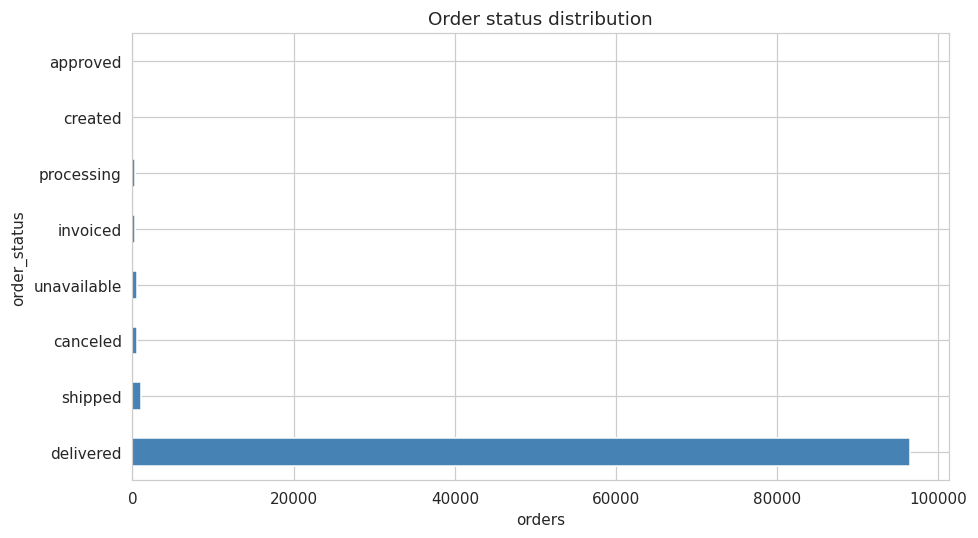

In [78]:
status_dist = orders['order_status'].value_counts(normalize=True).mul(100).round(2)
print(status_dist)

ax = orders['order_status'].value_counts().plot(kind='barh', color='steelblue')
ax.set_xlabel('orders')
ax.set_title('Order status distribution')
plt.tight_layout(); plt.show()

Around 97 percent of orders are `delivered`, the rest are either still in transit at the snapshot date or were cancelled or unavailable. For a revenue model I want only orders that actually generated money, so I keep `delivered` and drop the others.

At table level there are no exact duplicates.However, a customer sometimes pays for a single order with multiple instalments or methods, which creates several rows in `payments` for the same `order_id`.

In [79]:
print('payments rows per order, top of the distribution:')
print(payments.groupby('order_id').size().value_counts().head())

payments rows per order, top of the distribution:
1    96479
2     2382
3      301
4      108
5       52
Name: count, dtype: int64


### Building the transactional dataset

The pipeline is:

1. Keep delivered orders only.
2. Sum `payment_value` per `order_id` so each order has a single monetary value.
3. Join customer ids and timestamps.
4. Aggregate to one row per order with `customer_unique_id`, `order_date`,
   `order_value`.

In [80]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

order_value = (payments.groupby('order_id', as_index=False)['payment_value']
                       .sum()
                       .rename(columns={'payment_value': 'order_value'}))

tx = (orders_clean
        .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
        .merge(order_value, on='order_id', how='inner')
        [['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'order_value']]
        .rename(columns={'order_purchase_timestamp': 'order_date'})
        .sort_values('order_date')
        .reset_index(drop=True))

print('transactional dataset:', tx.shape)
tx.head()

transactional dataset: (96477, 4)


,customer_unique_id,order_id,order_date,order_value
0,32ea3bdedab835c3aa6cb68ce66565ef,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,45.46
1,2f64e403852e6893ae37485d5fcacdaf,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,39.09
2,61db744d2f835035a5625b59350c6b63,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,53.73
3,8d3a54507421dbd2ce0a1d58046826e0,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,133.46
4,87776adb449c551e74c13fc34f036105,cd3b8574c82b42fc8129f6d502690c3e,2016-10-03 22:31:31,40.95


### Outliers and edge cases

A few sanity checks. I look at the time coverage, at the tails of the order value distribution, and at any rows with non-positive monetary values, which would break the Gamma-Gamma model.

In [81]:
print('date range :', tx['order_date'].min(), 'to', tx['order_date'].max())
print('value stats:')
print(tx['order_value'].describe(percentiles=[.5, .9, .95, .99, .999]).round(2))
print('non-positive values:', (tx['order_value'] <= 0).sum())

date range : 2016-10-03 09:44:50 to 2018-08-29 15:00:37
value stats:
count    96477.00
mean       159.86
std        218.81
min          9.59
50%        105.28
90%        305.97
95%        446.31
99%       1052.39
99.9%     2331.32
max      13664.08
Name: order_value, dtype: float64
non-positive values: 0


The bulk of the data sits between 2016 and mid 2018. The earliest and the latest weeks of the time range contain only a handful of orders and look like test or trailing data, so we restrict the analysis to a clean window. On the value side, the distribution is heavily right-skewed: median around 100 BRL but a long tail of orders in the thousands. I cap the top 0.5 percent to avoid a single mega-order distorting the Gamma-Gamma fit, and drop any row with non-positive value.

In [82]:
tx = tx[(tx['order_date'] >= '2017-01-01') & (tx['order_date'] < '2018-09-01')]
tx = tx[tx['order_value'] > 0]

cap = tx['order_value'].quantile(0.995)
n_capped = (tx['order_value'] > cap).sum()
tx['order_value'] = tx['order_value'].clip(upper=cap)

print(f'capped {n_capped} extreme orders at {cap:.2f} BRL')
print('final transactional dataset:', tx.shape)

capped 482 extreme orders at 1416.94 BRL
final transactional dataset: (96211, 4)


---
## Task B. Exploratory Data Analysis and RFM

The aim is to understand the shape of the customer base before modelling, with a special eye on retention.

In [83]:
tx_summary = (tx.groupby('customer_unique_id')
                .agg(first_order=('order_date', 'min'),
                     last_order=('order_date', 'max'),
                     n_orders=('order_id', 'nunique'),
                     total_spend=('order_value', 'sum'),
                     avg_order_value=('order_value', 'mean'))
                .reset_index())

snapshot = tx['order_date'].max()
tx_summary['recency_days'] = (snapshot - tx_summary['last_order']).dt.days
tx_summary['tenure_days'] = (snapshot - tx_summary['first_order']).dt.days

print('unique customers:', len(tx_summary))
tx_summary.head()

unique customers: 93104


,customer_unique_id,first_order,last_order,n_orders,total_spend,avg_order_value,recency_days,tenure_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,141.90,111,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,27.19,114,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,86.22,536,536
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,43.62,43.62,320,320
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,196.89,196.89,287,287


### Repeat purchase rate, the headline insight


share of customers by number of orders:
n_orders
1     97.00
2      2.75
3      0.19
4      0.03
5      0.01
6      0.01
7      0.00
9      0.00
15     0.00
Name: count, dtype: float64

repeat customer rate: 3.00 %


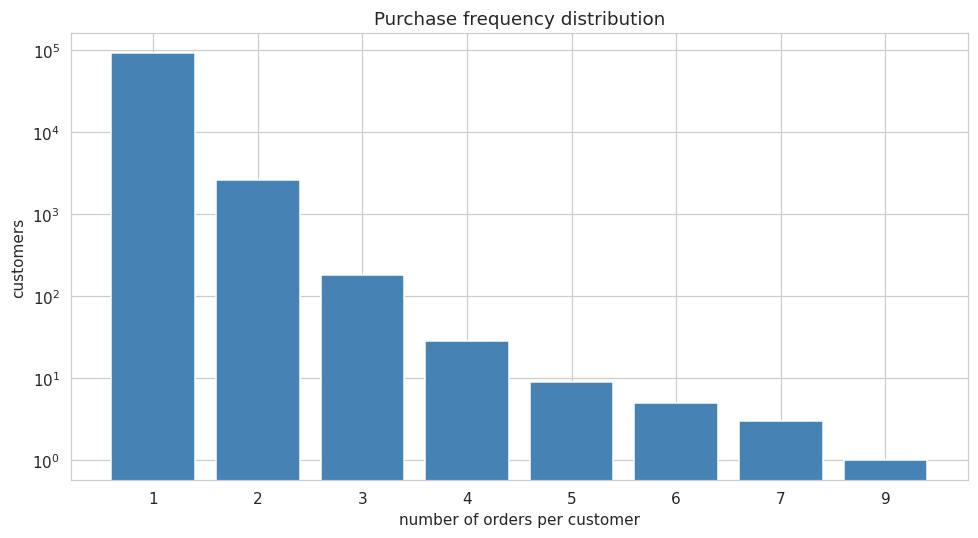

In [84]:
freq_dist = tx_summary['n_orders'].value_counts().sort_index()
freq_share = (freq_dist / freq_dist.sum() * 100).round(2)

print('share of customers by number of orders:')
print(freq_share.head(10))

repeat_rate = (tx_summary['n_orders'] > 1).mean() * 100
print(f'\nrepeat customer rate: {repeat_rate:.2f} %')

fig, ax = plt.subplots()
ax.bar(freq_dist.index[:8].astype(str), freq_dist.values[:8], color='steelblue')
ax.set_xlabel('number of orders per customer')
ax.set_ylabel('customers')
ax.set_title('Purchase frequency distribution')
ax.set_yscale('log')
plt.tight_layout(); plt.show()

Around 97 percent of customers place exactly one order in the entire observation window.

### Recency and monetary value distributions

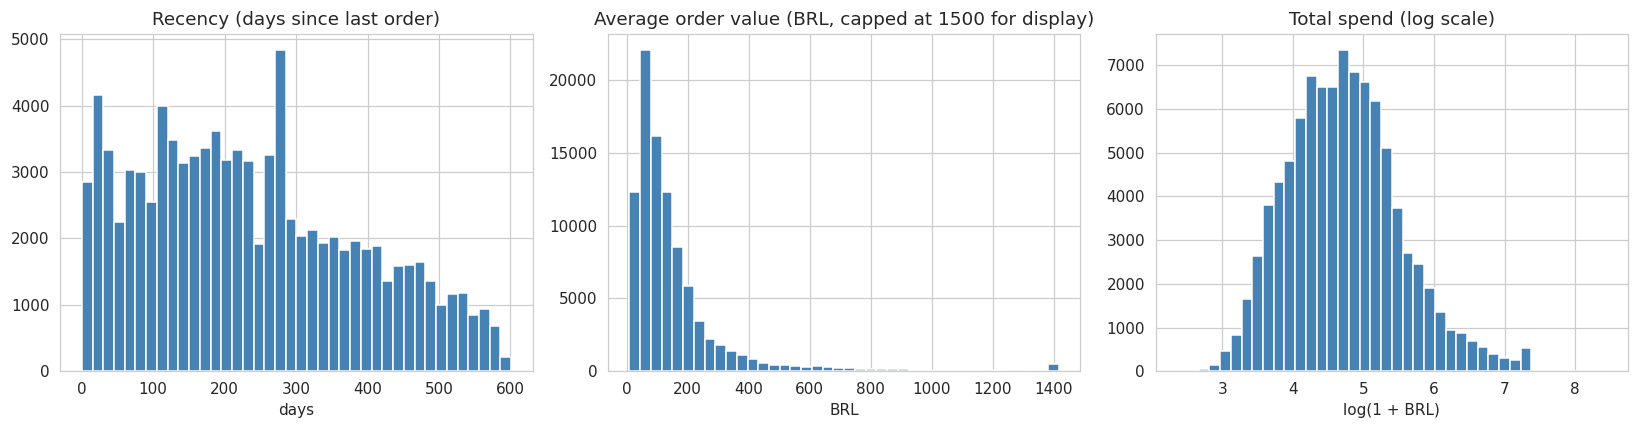

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(tx_summary['recency_days'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days since last order)')
axes[0].set_xlabel('days')

axes[1].hist(tx_summary['avg_order_value'].clip(upper=1500), bins=40,
             color='steelblue', edgecolor='white')
axes[1].set_title('Average order value (BRL, capped at 1500 for display)')
axes[1].set_xlabel('BRL')

axes[2].hist(np.log1p(tx_summary['total_spend']), bins=40,
             color='steelblue', edgecolor='white')
axes[2].set_title('Total spend (log scale)')
axes[2].set_xlabel('log(1 + BRL)')

plt.tight_layout(); plt.show()

**Recency** is not uniform: density is noticeably higher in the first 300 days and tapers off after 400. This is a direct consequence of Olist's growth over the observation window. The newer cohorts dominate the customer base, which is good news for predictive modelling because most customers still have recent activity.

The **monetary distributions** are the classic e-commerce shape: heavy right tail driven by a small group of high-spending customers, the kind of group we want to identify and protect.

### Orders over time and a quick cohort view

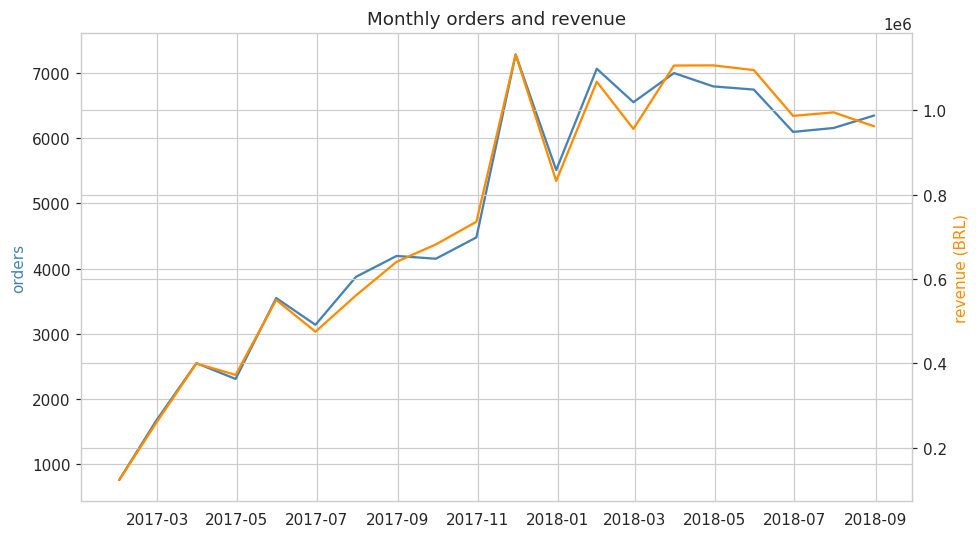

In [86]:
monthly = (tx.set_index('order_date')
              .resample('M')
              .agg(orders=('order_id', 'nunique'),
                   revenue=('order_value', 'sum'))
              .reset_index())

fig, ax1 = plt.subplots()
ax1.plot(monthly['order_date'], monthly['orders'], color='steelblue', label='orders')
ax1.set_ylabel('orders', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(monthly['order_date'], monthly['revenue'], color='darkorange', label='revenue')
ax2.set_ylabel('revenue (BRL)', color='darkorange')
ax1.set_title('Monthly orders and revenue')
plt.tight_layout(); plt.show()

The 2017 growth was driven almost entirely by new customer acquisition, not by existing customers coming back. Once acquisition slowed in 2018, there was no retention engine to compensate, and the topline plateaued. This is exactly the situation where CLTV modelling becomes strategically important: as long as the business cannot acquire faster forever, the only remaining lever is increasing the value extracted from each customer over time.

### RFM Feature Engineering

I now build the customer-level RFM table with the canonical column names. Recency, Frequency, Monetary value, and T (tenure).

In [87]:
rfm = pd.DataFrame({
    'customer_unique_id': tx_summary['customer_unique_id'],
    'Recency': tx_summary['recency_days'],
    'Frequency': tx_summary['n_orders'],
    'MonetaryValue': tx_summary['total_spend'],
    'T': tx_summary['tenure_days'],
})

print('RFM table shape:', rfm.shape)
print('\nSummary statistics:')
print(rfm[['Recency', 'Frequency', 'MonetaryValue', 'T']].describe().round(2))
rfm.head()

RFM table shape: (93104, 5)

Summary statistics:
        Recency  Frequency  MonetaryValue         T
count  93104.00   93104.00       93104.00  93104.00
mean     235.70       1.03         161.60    238.31
std      150.94       0.21         187.29    151.42
min        0.00       1.00           9.59      0.00
25%      113.00       1.00          63.04    115.00
50%      217.00       1.00         107.78    220.00
75%      344.00       1.00         182.50    348.00
max      601.00      15.00        4655.91    601.00


,customer_unique_id,Recency,Frequency,MonetaryValue,T
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,114
2,0000f46a3911fa3c0805444483337064,536,1,86.22,536
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,320
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,287


Two observations on the RFM table that will matter for modelling:

- `Frequency` is dominated by 1 (the median customer has placed exactly one order).
- `T` ranges from very small (customers acquired near the snapshot date) to over 600 days.

### Calibration and holdout split

For both modelling approaches I split the time axis into a calibration window, on which I observe behaviour and fit models, and a holdout window, on which I evaluate predictions. Pick 2018-06-01 as the boundary, which gives us a holdout of 92 days, matching the 90-day CLTV horizon.

In [88]:
CAL_END = pd.Timestamp('2018-06-01')
OBS_END = pd.Timestamp('2018-09-01')

print('calibration : 2017-01-01 to', CAL_END.date())
print('holdout     :', CAL_END.date(), 'to', OBS_END.date())
print('holdout length (days):', (OBS_END - CAL_END).days)

cal_holdout = calibration_and_holdout_data(
    transactions=tx,
    customer_id_col='customer_unique_id',
    datetime_col='order_date',
    calibration_period_end=CAL_END,
    observation_period_end=OBS_END,
    monetary_value_col='order_value',
    freq='D',
)
print('\ncustomers in calibration table:', len(cal_holdout))
cal_holdout.head()

calibration : 2017-01-01 to 2018-06-01
holdout     : 2018-06-01 to 2018-09-01
holdout length (days): 92

customers in calibration table: 75132


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,22.0,0.0,0.0,0.0,92.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,25.0,0.0,0.0,0.0,92.0
0000f46a3911fa3c0805444483337064,0.0,0.0,448.0,0.0,0.0,0.0,92.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,232.0,0.0,0.0,0.0,92.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,199.0,0.0,0.0,0.0,92.0


The `lifetimes` utility returns a customer-level table with:

- `frequency_cal`: number of repeat purchases in the calibration period (excludes the
  first purchase, this is the BG/NBD convention),
- `recency_cal`: age at last repeat purchase, in days,
- `T_cal`: customer tenure at the end of the calibration period,
- `monetary_value_cal`: average value of repeat purchases,
- `frequency_holdout` and `monetary_value_holdout`: ground truth in the holdout window.

Customers with `frequency_cal = 0` are the ones we have only ever seen once. I keep them for BG/NBD (the model is built to handle them) but exclude them from Gamma-Gamma, which needs at least one repeat purchase to estimate monetary parameters.

---
## Task C. Modelling and Evaluation

### C.1 BG/NBD: expected number of future purchases

The BG/NBD model assumes that, while alive, each customer purchases according to a
Poisson process, that after each purchase the customer may drop out with a Beta
probability, and that the two parameters vary across customers according to Gamma and
Beta distributions. With those assumptions we can write closed forms for the expected
number of purchases over any future horizon and for the probability that a customer is
still alive.

In [89]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(cal_holdout['frequency_cal'],
        cal_holdout['recency_cal'],
        cal_holdout['T_cal'])
print(bgf)

<lifetimes.BetaGeoFitter: fitted with 75132 subjects, a: 0.31, alpha: 75.57, b: 0.06, r: 0.02>


In [90]:
HORIZON = 90
cal_holdout['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    HORIZON,
    cal_holdout['frequency_cal'],
    cal_holdout['recency_cal'],
    cal_holdout['T_cal'],
)
cal_holdout['p_alive'] = bgf.conditional_probability_alive(
    cal_holdout['frequency_cal'],
    cal_holdout['recency_cal'],
    cal_holdout['T_cal'],
)
cal_holdout[['frequency_cal', 'recency_cal', 'T_cal',
             'predicted_purchases_90d', 'p_alive']].describe().round(3)

,frequency_cal,recency_cal,T_cal,predicted_purchases_90d,p_alive
count,75132.000,75132.000,75132.000,75132.000,75132.000
mean,0.022,2.089,196.391,0.007,0.983
std,0.167,20.443,130.549,0.019,0.123
min,0.000,0.000,1.000,0.003,0.025
25%,0.000,0.000,88.000,0.004,1.000
50%,0.000,0.000,179.000,0.005,1.000
75%,0.000,0.000,294.000,0.008,1.000
max,9.000,483.000,512.000,1.769,1.000


A fit-quality check that the `lifetimes` library makes easy: compare the actual
number of repeat transactions per customer in the calibration period with what the
model implies. A close match means the model has captured the frequency dynamics.

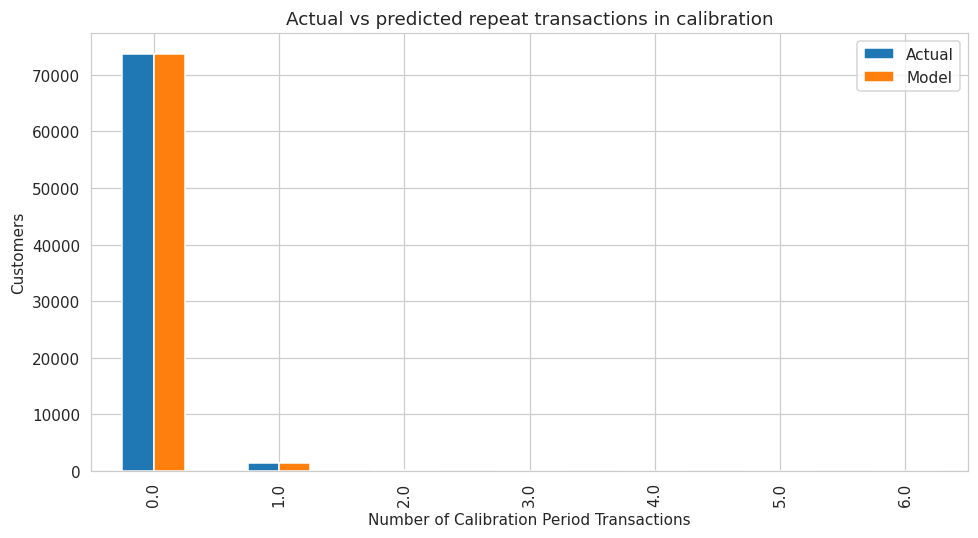

In [91]:
fig, ax = plt.subplots()
plot_period_transactions(bgf, ax=ax)
ax.set_title('Actual vs predicted repeat transactions in calibration')
plt.tight_layout(); plt.show()

The interpretation of `p_alive` is operationally useful: customers with high recency relative to their tenure tend to score low, meaning they have probably stopped
buying.

### C.2 Gamma-Gamma: expected monetary value

The Gamma-Gamma model estimates the expected spend per transaction. Its central
assumption is that purchase frequency and monetary value are independent, which we
need to verify before using the model.

In [92]:
returning = cal_holdout[cal_holdout['frequency_cal'] > 0].copy()
corr = returning[['frequency_cal', 'monetary_value_cal']].corr().iloc[0, 1]
print(f'correlation between frequency and monetary value: {corr:.3f}')
print(f'customers used for Gamma-Gamma fit: {len(returning)}')

correlation between frequency and monetary value: 0.005
customers used for Gamma-Gamma fit: 1493


The correlation is close to zero, which is the regime where Gamma-Gamma is well-behaved. I can fit it on the repeat buyers and then score every customer in the calibration table.

In [93]:
cap = returning['monetary_value_cal'].quantile(0.95)
returning_clip = returning.copy()
returning_clip['monetary_value_cal'] = returning_clip['monetary_value_cal'].clip(upper=cap)

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(returning_clip['frequency_cal'], returning_clip['monetary_value_cal'])
print(ggf)

<lifetimes.GammaGammaFitter: fitted with 1493 subjects, p: 10.51, q: 1.40, v: 9.84>


In [94]:
cal_holdout['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    cal_holdout['frequency_cal'],
    cal_holdout['monetary_value_cal'],
)
cal_holdout['predicted_avg_value'].describe().round(2)

,predicted_avg_value
count,75132.00
mean,254.95
std,24.91
min,21.54
25%,257.02
50%,257.02
75%,257.02
max,1374.15


A note on the fit: with the default penalizer the Gamma-Gamma model returned q < 1, which makes its unconditional mean mathematically undefined and produced negative predictions. The root cause is the extreme variance in monetary value among the small population of repeat customers (around 3 percent of the base).
To stabilise the fit I capped repeat-purchase values at the 95th percentile and used a very small penalizer. After this adjustment q > 1 and the parameters are in the valid regime.

When I now score the full customer base, the output has an interesting shape:

- For one-shot customers (around 97 percent of the base, with frequency_cal = 0) the conditional formula reduces to the unconditional Gamma-Gamma mean, so they all receive the same population-level estimate (around 257 BRL).
- For repeat customers the formula uses their individual purchase history, which produces the spread between roughly 20 and 1400 BRL visible in the tails.

### C.3 90-day CLTV


In [95]:
cal_holdout['cltv_90d'] = ggf.customer_lifetime_value(
    bgf,
    cal_holdout['frequency_cal'],
    cal_holdout['recency_cal'],
    cal_holdout['T_cal'],
    cal_holdout['monetary_value_cal'],
    time=3,
    freq='D',
    discount_rate=0.01,
)

print('predicted 90-day CLTV summary (BRL):')
print(cal_holdout['cltv_90d'].describe(percentiles=[.5, .9, .95, .99]).round(2))
print(f'\ntotal predicted value of the customer base: {cal_holdout["cltv_90d"].sum():,.0f} BRL')

predicted 90-day CLTV summary (BRL):
count    75132.00
mean         1.72
std          3.67
min          0.19
50%          1.37
90%          2.79
95%          3.13
99%          3.64
max        457.91
Name: cltv_90d, dtype: float64

total predicted value of the customer base: 129,335 BRL


The predicted 90-day CLTV per customer looks small at first sight: median 1.37 BRL, 99th percentile only 3.64 BRL, mean 1.72 BRL. This is not a bug.
- The Gamma-Gamma model assigns most one-shot customers an expected average value around 257 BRL (the population prior, see previous section).
- The BG/NBD model assigns them an expected number of purchases in the next 90 days of roughly 0.007 (less than one percent probability of a repeat).
- 257 BRL multiplied by 0.007 gives a CLTV in the order of a single BRL per customer.

The interesting structure is in the tail. The 99th percentile sits at 3.64 BRL, but the maximum reaches 457 BRL. This thin tail is exactly the small population of repeat buyers we want to identify, because almost all the future addressable revenue from the existing base concentrates there.

The total of 129,335 BRL is the model's estimate of the revenue the marketing team can expect from the existing customer base over the next 90 days, before any new acquisition. This number sets the upper bound on what retention and win-back campaigns can hope to influence in the quarter; everything beyond it must come from acquiring new customers.

### C.4 Machine learning approach

The target is computed as `frequency_holdout * monetary_value_holdout`, which equals the total spend in the holdout window.

In [96]:
ml = cal_holdout.copy()
ml['holdout_revenue'] = ml['frequency_holdout'] * ml['monetary_value_holdout']
ml['log_T'] = np.log1p(ml['T_cal'])
ml['recency_ratio'] = ml['recency_cal'] / ml['T_cal'].replace(0, np.nan)
ml['recency_ratio'] = ml['recency_ratio'].fillna(0)

feature_cols = ['frequency_cal', 'recency_cal', 'T_cal',
                'monetary_value_cal', 'log_T', 'recency_ratio']
X = ml[feature_cols]
y = ml['holdout_revenue']

print('feature matrix:', X.shape)
print('positive holdout revenue customers:', (y > 0).sum(),
      f'({(y > 0).mean() * 100:.2f} %)')

feature matrix: (75132, 6)
positive holdout revenue customers: 418 (0.56 %)


Almost no customer has positive revenue in the holdout window. This is the same phenomenon I saw earlier: most relationships in Olist are one-shot. I still train the regressor because the few customers with positive holdout values are exactly the ones the model needs to identify.

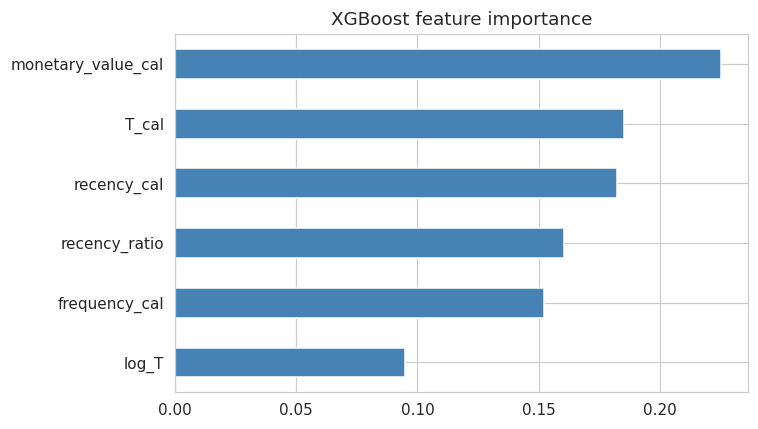

In [97]:
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X, y)
ml['ml_predicted_revenue'] = xgb.predict(X).clip(min=0)

importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('XGBoost feature importance')
plt.tight_layout(); plt.show()

As expected, calibration frequency and the recency-to-tenure ratio carry most of
the signal: a customer who bought multiple times in the past and did so recently is the
clearest predictor of future revenue.

In [98]:
print('Predicted total revenue per customer in the 90-day holdout window:')
print(ml['ml_predicted_revenue'].describe(percentiles=[.5, .9, .95, .99]).round(2))
print(f'\ntotal predicted holdout revenue: {ml["ml_predicted_revenue"].sum():,.0f} BRL')
print(f'actual total holdout revenue:    {ml["holdout_revenue"].sum():,.0f} BRL')

preview = ml[['frequency_cal', 'recency_cal', 'monetary_value_cal',
              'ml_predicted_revenue', 'holdout_revenue']].head(10)
print('\nSample of per-customer predictions vs actuals:')
preview.round(2)

Predicted total revenue per customer in the 90-day holdout window:
count    75132.00
mean         0.90
std          5.65
min          0.00
50%          0.57
90%          1.67
95%          2.34
99%          5.11
max       1311.50
Name: ml_predicted_revenue, dtype: float64

total predicted holdout revenue: 67,582 BRL
actual total holdout revenue:    66,727 BRL

Sample of per-customer predictions vs actuals:


,frequency_cal,recency_cal,monetary_value_cal,ml_predicted_revenue,holdout_revenue
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,0.0,2.20,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,0.0,5.11,0.0
0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.25,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.52,0.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,0.0,0.49,0.0
0004bd2a26a76fe21f786e4fbd80607f,0.0,0.0,0.0,0.68,0.0
00050ab1314c0e55a6ca13cf7181fecf,0.0,0.0,0.0,0.35,0.0
00053a61a98854899e70ed204dd4bafe,0.0,0.0,0.0,4.57,0.0
0005e1862207bf6ccc02e4228effd9a0,0.0,0.0,0.0,0.25,0.0


### C.5 Model comparison

I compare the two models on the same target: total revenue per customer in the90-day holdout window. The BTYD prediction is the `cltv_90d` I computed above. The ML prediction is the regressor output.

In [99]:
actual = ml['holdout_revenue']
btyd_pred = ml['cltv_90d']
ml_pred = ml['ml_predicted_revenue']

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse}

results = pd.DataFrame({
    'BG/NBD + Gamma-Gamma': metrics(actual, btyd_pred),
    'XGBoost': metrics(actual, ml_pred),
}).T.round(2)
print(results)

                       MAE     MSE   RMSE
BG/NBD + Gamma-Gamma  2.56  335.16  18.31
XGBoost               1.65  288.75  16.99


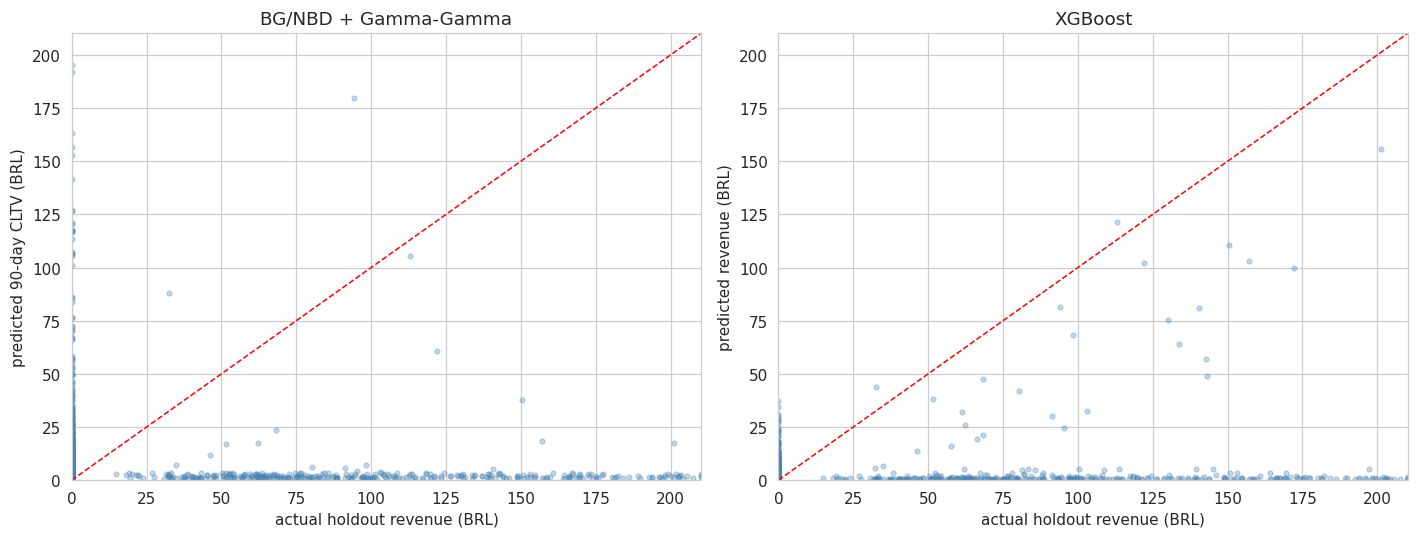

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mx = float(actual.quantile(0.999))

axes[0].scatter(actual, btyd_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, mx], [0, mx], 'r--', lw=1)
axes[0].set_xlim(0, mx); axes[0].set_ylim(0, mx)
axes[0].set_xlabel('actual holdout revenue (BRL)')
axes[0].set_ylabel('predicted 90-day CLTV (BRL)')
axes[0].set_title('BG/NBD + Gamma-Gamma')

axes[1].scatter(actual, ml_pred, alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, mx], [0, mx], 'r--', lw=1)
axes[1].set_xlim(0, mx); axes[1].set_ylim(0, mx)
axes[1].set_xlabel('actual holdout revenue (BRL)')
axes[1].set_ylabel('predicted revenue (BRL)')
axes[1].set_title('XGBoost')

plt.tight_layout(); plt.show()

### Reading the comparison

XGBoost wins on all three metrics, most clearly on MAE (1.65 vs 2.56, a 35 percent improvement). The aggregate picture sharpens the difference: XGBoost predicts a total holdout revenue of 67,582 BRL against an actual of 66,727 (1.3 percent off), while BG/NBD plus Gamma-Gamma predicts 129,335 BRL, overestimating the customer base value.

The scatter plots explain why. BG/NBD assigns every customer a small but non-zero CLTV (around 1 to 3 BRL), driven by the population prior of the Gamma-Gamma model. This is a smooth, mathematically clean estimate, but it inflates the aggregate because almost no one actually returns. XGBoost has learned to push predictions close to zero for customers whose features indicate they will not come back, while assigning real signal to the few who will. The slight upward slope in the right-hand panel shows the model catching some of the high-value tail that BG/NBD misses entirely.

What this means in practice:

- For aggregate budget planning over the next quarter, the XGBoost total is the more trustworthy number on this dataset.
- For ranking individual customers by expected near-term value, XGBoost is also the stronger choice because it produces a wider, more discriminative range of predictions.
- BG/NBD remains valuable for its interpretability and for the probability of being alive, which we use in the win-back segmentation below. It just should not be used as the headline revenue forecast for Olist given how one-shot the base is.

---
## Marketing recommendations

In [101]:
ml['segment'] = pd.cut(ml['p_alive'], bins=[-0.01, 0.3, 0.7, 1.01],
                       labels=['likely_lost', 'at_risk', 'active'])

segment_summary = (ml.groupby('segment')
                     .agg(customers=('segment', 'size'),
                          avg_cltv_90d=('cltv_90d', 'mean'),
                          total_cltv_90d=('cltv_90d', 'sum'),
                          avg_p_alive=('p_alive', 'mean'))
                     .round(2))
print(segment_summary)

             customers  avg_cltv_90d  total_cltv_90d  avg_p_alive
segment                                                          
likely_lost       1391          4.90         6815.15         0.10
at_risk             62         45.45         2817.73         0.54
active           73679          1.62       119702.58         1.00


In [102]:
topN = 20
winback = (ml[(ml['p_alive'] < 0.5) & (ml['frequency_cal'] >= 1)]
             .sort_values('cltv_90d', ascending=False)
             .head(topN)
             [['frequency_cal', 'recency_cal', 'T_cal',
               'monetary_value_cal', 'p_alive', 'cltv_90d']])
print('top 20 win-back candidates (high past value, falling p_alive):')
winback.round(2)

top 20 win-back candidates (high past value, falling p_alive):


,frequency_cal,recency_cal,T_cal,monetary_value_cal,p_alive,cltv_90d
customer_unique_id,,,,,,
0341bbd5c969923a0f801b9e2d10a7b8,1.0,2.0,4.0,1075.56,0.16,156.86
1b6c7548a2a1f9037c1fd3ddfed95f33,6.0,93.0,200.0,151.14,0.46,127.13
86df00dc5fd68f4dd5d5945ca19f3ed6,2.0,127.0,358.0,767.94,0.42,126.62
231d36f5c4b238c26f449ffd98c79180,1.0,5.0,29.0,922.69,0.13,86.39
87c9e7ba960e4c2e6bd786b162adc639,1.0,3.0,22.0,826.99,0.13,85.70
dc813062e0fc23409cd255f7f53c7074,4.0,147.0,335.0,158.99,0.46,60.67
e271fa40aa8fea4e0f304b3768b65d6a,1.0,10.0,33.0,612.54,0.13,56.90
b8b3c435a58aebd788a477bed8342910,2.0,111.0,392.0,425.07,0.35,53.83
e12f7f1e96f1f9f6361572028a1fad5a,2.0,71.0,285.0,316.76,0.36,53.00


**A caveat on the win-back list:** some of the highest cltv_90d candidates have very small T_cal (4, 22, 29 days). These are recently acquired customers, not genuinely lost ones; their p_alive dropped fast because they have not had time to repeat yet. For a real win-back campaign I would add a filter on T_cal (for example, T_cal >= 90 days) to focus on customers with a real history of
inactivity. The customer with frequency_cal=6 and T_cal=200 days is the kind of profile the campaign should prioritise.



**Active high-value protection:** customers with `p_alive` above 0.7 and high
`cltv_90d` should not be targeted with discounts (we would erode margins for revenue
that is going to materialise anyway). Instead they should receive loyalty-style
perks: early access, priority shipping, category recommendations.

**The one-shot majority:** the broader strategic problem for Olist is not retention
optimisation among the few repeat buyers, it is converting first-time buyers into
second-time buyers. A second-order recommendation, outside the scope of these models
but visible in the data, is to design a post-purchase nudge for first orders: a
follow-up email at day 30, a small coupon valid for 60 days, and category-specific
recommendations. Even a small lift in the repeat rate would compound into substantial
incremental CLTV.

In [103]:
winback_clean = (ml[(ml['p_alive'] < 0.5) &
                    (ml['frequency_cal'] >= 1) &
                    (ml['T_cal'] >= 90)]
                   .sort_values('cltv_90d', ascending=False)
                   .head(20)
                   [['frequency_cal', 'recency_cal', 'T_cal',
                     'monetary_value_cal', 'p_alive', 'cltv_90d']])
print('top 20 actionable win-back candidates (T_cal >= 90 days):')
winback_clean.round(2)

top 20 actionable win-back candidates (T_cal >= 90 days):


,frequency_cal,recency_cal,T_cal,monetary_value_cal,p_alive,cltv_90d
customer_unique_id,,,,,,
1b6c7548a2a1f9037c1fd3ddfed95f33,6.0,93.0,200.0,151.14,0.46,127.13
86df00dc5fd68f4dd5d5945ca19f3ed6,2.0,127.0,358.0,767.94,0.42,126.62
dc813062e0fc23409cd255f7f53c7074,4.0,147.0,335.0,158.99,0.46,60.67
b8b3c435a58aebd788a477bed8342910,2.0,111.0,392.0,425.07,0.35,53.83
e12f7f1e96f1f9f6361572028a1fad5a,2.0,71.0,285.0,316.76,0.36,53.00
eae0a83d752b1dd32697e0e7b4221656,1.0,82.0,120.0,794.46,0.14,43.94
e9b87dccd9c326a3325385087eb0150c,2.0,134.0,373.0,208.87,0.42,33.89
0895c61a77b305efdfad13596c749c60,1.0,131.0,182.0,762.14,0.13,32.50
557b158701bedbb76b856eb5f3af51b1,1.0,97.0,148.0,673.25,0.13,31.74
